In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

<h3>Create a dataset from images in a directory</h3>

In [32]:
directory = "/home/samani/Documents/projects/deep-learning/data/transfer_learning/"
batch_size = 16
image_size = (224, 224)


training_set = tf.keras.preprocessing.image_dataset_from_directory(
    directory, 
    shuffle=True,
    batch_size=batch_size, 
    image_size=image_size,
    validation_split=0.2,
    subset="training",
    seed=12
)

validation_set = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    shuffle=True,
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.2,
    subset="validation",
    seed=12
)

Found 327 files belonging to 2 classes.
Using 262 files for training.
Found 327 files belonging to 2 classes.
Using 65 files for validation.


In [33]:
class_names = training_set.class_names
class_names

['alpaca', 'not alpaca']

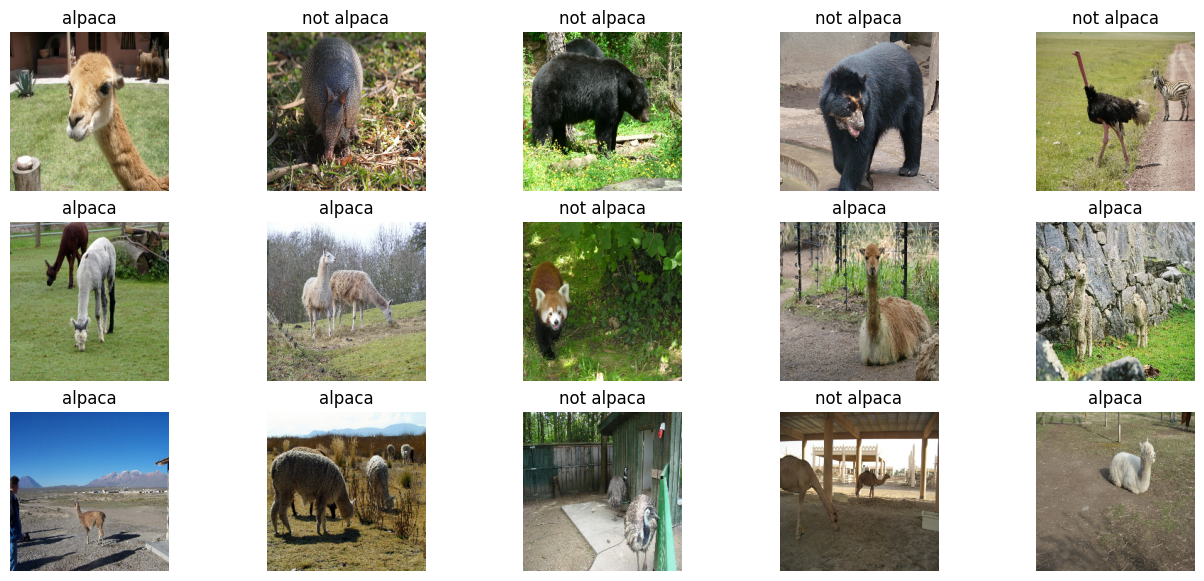

2024-05-21 19:31:41.881049: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [34]:
plt.figure(figsize=(16, 7))

for images, lables in training_set.take(1):
    for i in range(1, 16):
        ax = plt.subplot(3, 5, i)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[lables[i]])
        plt.axis("off")
    plt.show()

In [35]:
"""
Using prefetch() prevents a memory bottleneck that can occur when reading from disk. 
It sets aside some data and keeps it ready for when it's needed, by creating a source
dataset from your input data, applying a transformation to preprocess it, then iterating
over the dataset one element at a time. Because the iteration is streaming, 
the data doesn't need to fit into memory.
"""
training_set = training_set.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

<h3>Data Augmentation</h3>

In [36]:
def data_augmentor():
    
    data_augmentation = tf.keras.Sequential()
    data_augmentation.add(tf.keras.layers.RandomFlip(mode="horizontal"))
    data_augmentation.add(tf.keras.layers.RandomRotation(0.2))
 
    return data_augmentation

2024-05-21 19:31:45.953318: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


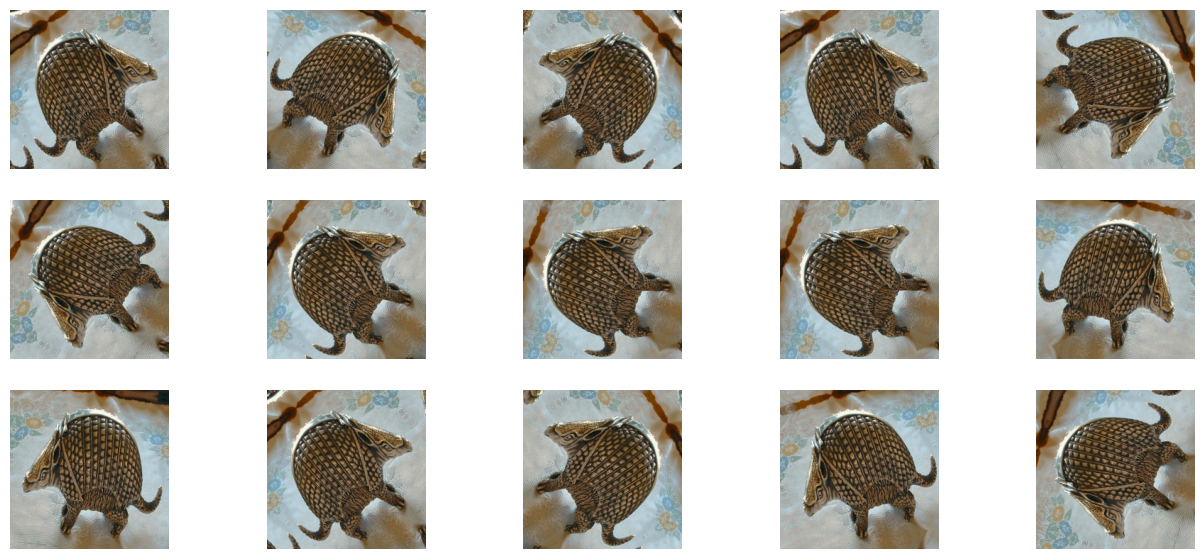

In [37]:
data_augmentation = data_augmentor()


for image, _ in training_set.take(1):

    plt.figure(figsize=(16, 7))
    first_image = image[0]
    for i in range(1, 16):
        ax = plt.subplot(3, 5, i)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255.0)
        plt.axis("off")

<h4>Notes:</h4>

    1. When calling image_data_set_from_directory(), specify the train/val subsets and match the seeds to prevent overlap
    2. Use prefetch() to prevent memory bottlenecks when reading from disk
    3. Give your model more to learn from with simple data augmentations like rotation and flipping.
    4. When using a pretrained model, it's best to reuse the weights it was trained on.



<h3>Using MobileNetV2 for transfer learning </h3>

In [38]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=image_size + (3, ), 
    include_top=True, 
    weights="imagenet" #   load the pretrained weights from ImageNet
)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [39]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)


    MobileNetV2's unique features are:
        Depthwise separable convolutions that provide lightweight feature filtering and creation
        Input and output bottlenecks that preserve important information on either end of the block
    Depthwise separable convolutions deal with both spatial and depth (number of channels) dimensions


In [81]:
def mobile_net_model(image_shape=image_size, data_augmentation=data_augmentor()):

    input_shape = image_shape + (3, )

    model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    
    # freeze the model
    model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    X = data_augmentation(inputs)
    X = model(X, training=False)
    
    # add the new Binary classification layers
    X = tf.keras.layers.GlobalAveragePooling2D()(X)
    X = tf.keras.layers.Dropout(0.2)(X)
    outputs = tf.keras.layers.Dense(units=1, activation="linear")(X)

    model = tf.keras.Model(inputs, outputs)
    
    return model

In [87]:
def train(train_set, val_set, model=mobile_net_model(), learning_rate=1e-3, epochs=10):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=["accuracy"] 
    )

    history = model.fit(train_set, validation_data=val_set, epochs=epochs)

    return model, history

In [88]:
model1, history = train(training_set, validation_set)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 439ms/step - accuracy: 0.4887 - loss: 0.8572 - val_accuracy: 0.4769 - val_loss: 0.6778
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 359ms/step - accuracy: 0.4972 - loss: 0.7554 - val_accuracy: 0.4769 - val_loss: 0.6660
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.4997 - loss: 0.7352 - val_accuracy: 0.4769 - val_loss: 0.6612
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.5755 - loss: 0.6652 - val_accuracy: 0.4615 - val_loss: 0.6568
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 357ms/step - accuracy: 0.5103 - loss: 0.6999 - val_accuracy: 0.5077 - val_loss: 0.6586
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 356ms/step - accuracy: 0.5153 - loss: 0.6790 - val_accuracy: 0.4769 - val_loss: 0.6560
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 357ms/step - accuracy: 0.5730 - loss: 0.6503 - val_accuracy: 0.4615 - val_loss: 0.6605
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.5935 - loss: 0.6569 - val_accuracy: 0

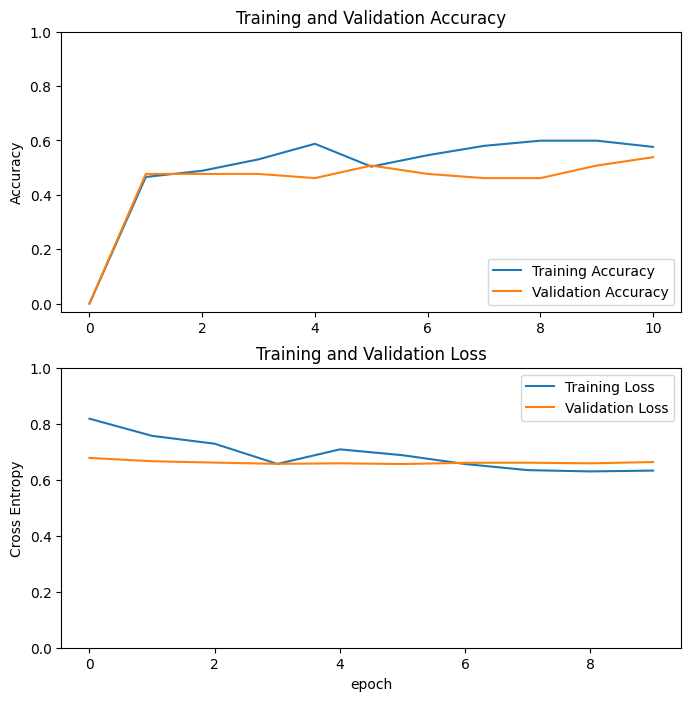

In [89]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

<h3>Fine Tuning</h3>

You could try fine-tuning the model by re-running the optimizer in the last layers to improve accuracy. When you use a smaller learning rate, you take smaller steps to adapt it a little more closely to the new data. In transfer learning, the way you achieve this is by unfreezing the layers at the end of the network, and then re-training your model on the final layers with a very low learning rate. Adapting your learning rate to go over these layers in smaller steps can yield more fine details - and higher accuracy.

In [93]:
def train1(train_set, val_set, model, learning_rate=1e-3*0.1, epochs=20, fine_tune_at=120):

    model.trainable = True
    # Freeze all the layers before the `fine_tune_at` layer
    for layer in model.layers[:fine_tune_at]:
        layer.trainable = False
    
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=["accuracy"] 
    )

    history = model.fit(train_set, validation_data=val_set, epochs=epochs)

    return history

In [95]:
history1 = train1(training_set, validation_set, model1)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 392ms/step - accuracy: 0.5908 - loss: 0.6808 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.7017 - loss: 0.6364 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 347ms/step - accuracy: 0.6908 - loss: 0.6193 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 373ms/step - accuracy: 0.6202 - loss: 0.6283 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 369ms/step - accuracy: 0.6569 - loss: 0.6245 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.6674 - loss: 0.5771 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.6522 - loss: 0.6120 - val_accuracy: 0.5385 - val_loss: 0.6632
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.5531 - loss: 0.6758 - val_accuracy: 0.

In [96]:
acc += history1.history['accuracy']
val_acc += history1.history['val_accuracy']

loss += history1.history['loss']
val_loss += history1.history['val_loss']

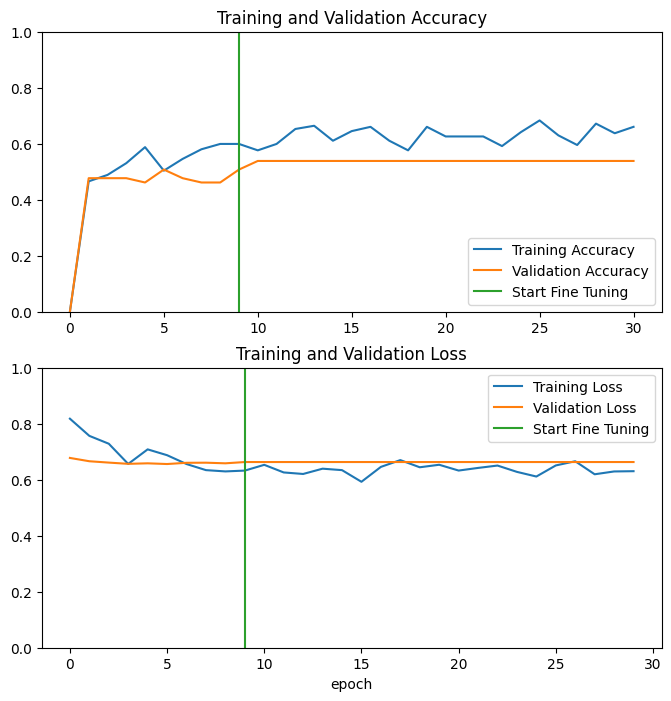

In [99]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([10-1,10-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([10-1,10-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()